# ALLaM-7B — Arabic Document Sensitivity Classification
Multi-shot evaluation (Zero / One / Three-Shot) using **ALLaM-7B-Instruct**, an Arabic-specialized LLM.
Classification follows **NDMO/SDAIA** sensitivity levels: عام · مقيد · سري · سري للغاية

## 0. Setup

In [ ]:
# Install all required libraries
# pyarrow pinned to 14.0.1 to avoid compatibility issues with datasets
!pip uninstall -y pyarrow
!pip install -q pyarrow==14.0.1
!pip install -q -U bitsandbytes transformers accelerate peft trl datasets \
                   sentencepiece tiktoken scikit-learn seaborn matplotlib \
                   arabic-reshaper python-bidi


Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 69.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires pyarrow>=15.0.0; platform_machine == "x86_64", but you have pyarrow 14.0.1 which is incompatible.
bigframes 2.40.0 requires pyarrow>=15.0.2, but you have pyarrow 14.0.1 which is incompatible.
datasets 4.0.0 requires pyarrow>=15.0.0, but you have pyarrow 14.0.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 168.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 63.5 MB/s eta 0:00:00
 

In [ ]:
# ── Imports ──────────────────────────────────────────────
import os, re, torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive, userdata
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
import arabic_reshaper
from bidi.algorithm import get_display


In [ ]:
# ── Mount Google Drive & Authenticate ───────────────────
# Clear any stale mount before remounting
if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    !rm -rf /content/drive/*

drive.mount('/content/drive', force_remount=True)

token = userdata.get('HF_TOKEN')
if token:
    login(token=token)
    print("Logged in to Hugging Face successfully.")
else:
    print("HF_TOKEN not found in Colab secrets.")


Mounted at /content/drive
Logged in to Hugging Face successfully.


In [ ]:
# ── Paths & Global Constants ─────────────────────────────
BASE_MODEL_ID  = "humain-ai/ALLaM-7B-Instruct-preview"
DATASET_PATH   = "/content/drive/MyDrive/GP/Modified_Data.csv"
PROJECT_DIR    = "/content/drive/MyDrive/allam_project"
VALID_CLASSES  = ["عام", "مقيد", "سري", "سري للغاية"]
DISPLAY_LABELS = ["Public", "Restricted", "Secret", "Top Secret"]
LABEL_MAP      = dict(zip(VALID_CLASSES, DISPLAY_LABELS))

os.makedirs(PROJECT_DIR, exist_ok=True)


## 1. Data Preparation

In [ ]:
# Load dataset and create locked 85/15 train/test split (seed=42)
df_full = pd.read_csv(DATASET_PATH)
_, test_df = train_test_split(df_full, test_size=0.15, random_state=42)
test_df = test_df.reset_index(drop=True)

print(f"Test set: {len(test_df)} documents")
print(f"Class distribution:\n{test_df['sensitivity_level'].value_counts()}")


Test set: 6000 documents
Class distribution:
sensitivity_level
سري           1519
عام           1515
سري للغاية    1501
مقيد          1465
Name: count, dtype: int64


In [ ]:
# Format training data into ALLaM prompt+answer format
SYSTEM_MSG = "أنت نظام خبير في تصنيف حساسية الوثائق العربية حسب معايير NDMO."

def format_prompt_allam(row):
    content = str(row['content']) if pd.notnull(row['content']) else ""
    label   = str(row['sensitivity_level']) if pd.notnull(row['sensitivity_level']) else "عام"
    user_msg = f"صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية).\nالوثيقة: {content}"
    return {"text": f"### نظام:\n{SYSTEM_MSG}\n\n### مستخدم:\n{user_msg}\n\n### مساعد:\n{label}"}

dataset = Dataset.from_pandas(df_full)
dataset = dataset.map(format_prompt_allam, remove_columns=dataset.column_names)
train_data = dataset.train_test_split(test_size=0.15, seed=42)['train']

print(f"Training samples: {len(train_data)}")
print("\nSample prompt:")
print(train_data[0]['text'][:300] + "...")


Training samples: 34000

Sample prompt:
### نظام:
أنت نظام خبير في تصنيف حساسية الوثائق العربية حسب معايير NDMO.

### مستخدم:
صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية).
الوثيقة: حرصًا على اتساق الإجراءات، نعرض التحديثات التالية ضمن متابعة المخاطر مؤخرًا، مع الإشارة للخطوات اللاحقة. إلحاقًا للمتابعة السابقة، نرفق ...


## 2. Load ALLaM-7B Model

In [ ]:
# ── Load Tokenizer & Model ───────────────────────────────
# Left padding prevents hallucination during batch generation
print("Loading ALLaM-7B model and tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()
print("Model loaded and ready for inference.")


Loading ALLaM-7B model and tokenizer...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded and ready for inference.


## 3. Helper Functions

In [ ]:
def clean_prediction(pred_text):
    """Extract a valid Arabic sensitivity label from raw model output."""
    if not isinstance(pred_text, str):
        return "Unknown"
    for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
        if cls in pred_text:
            return cls
    return "Unknown"


def fix_arabic(text):
    """Reshape and apply BiDi for correct Arabic rendering in matplotlib."""
    return get_display(arabic_reshaper.reshape(str(text)))


def run_inference(contents, actual_labels, build_prompt_fn, save_file, batch_size=1, max_length=1024):
    """Run inference with auto-resume support (saves every 100 records)."""
    if os.path.exists(save_file):
        saved_df = pd.read_csv(save_file)
        processed = set(saved_df.index.tolist())
        print(f"Resuming: {len(processed)} documents already processed.")
    else:
        processed = set()
        pd.DataFrame(columns=['Actual', 'Predicted']).to_csv(save_file, index=False)
        print("Starting fresh evaluation.")

    remaining_idx  = [i for i in range(len(contents)) if i not in processed]
    rem_contents   = [contents[i] for i in remaining_idx]
    rem_labels     = [actual_labels[i] for i in remaining_idx]

    if not rem_contents:
        print("All documents already classified."); return

    print(f"Classifying {len(rem_contents)} documents...")
    batch_results = []

    with torch.no_grad():
        for i, (text, actual) in enumerate(tqdm(zip(rem_contents, rem_labels),
                                                total=len(rem_contents))):
            prompt = build_prompt_fn(str(text))
            inputs = tokenizer(prompt, return_tensors="pt",
                               truncation=True, max_length=max_length).to("cuda")

            outputs = model.generate(
                **inputs, max_new_tokens=8, temperature=0.01,
                do_sample=False, pad_token_id=tokenizer.eos_token_id
            )

            response = tokenizer.decode(
                outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
            ).strip()

            batch_results.append({'Actual': actual, 'Predicted': clean_prediction(response)})

            # Save every 100 records to avoid losing progress
            if (i + 1) % 100 == 0:
                pd.DataFrame(batch_results).to_csv(save_file, mode='a', header=False, index=False)
                batch_results = []
                torch.cuda.empty_cache()

    if batch_results:
        pd.DataFrame(batch_results).to_csv(save_file, mode='a', header=False, index=False)

    print(f"Saved to: {save_file}")


def evaluate_and_plot(save_file, title):
    """Print classification report and plot confusion matrix from results CSV."""
    df = pd.read_csv(save_file)
    df['Predicted'] = df['Predicted'].apply(clean_prediction)

    actual_en    = [LABEL_MAP.get(l, "Unknown") for l in df['Actual']]
    predicted_en = [LABEL_MAP.get(l, "Unknown") for l in df['Predicted']]

    print(f"\n{'='*55}\nResults: {title}\n{'='*55}")
    print(classification_report(actual_en, predicted_en, labels=DISPLAY_LABELS, digits=4))

    cm = confusion_matrix(actual_en, predicted_en, labels=DISPLAY_LABELS)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS)
    plt.title(title, fontsize=13)
    plt.xlabel("Predicted", fontsize=11)
    plt.ylabel("Actual", fontsize=11)
    plt.tight_layout()
    plt.show()


## 4. Zero-Shot Evaluation
No examples in the prompt — tests the model's base sensitivity knowledge.

Found 6000 already evaluated documents.

Performance Report (ALLaM Zero-Shot):
              precision    recall  f1-score   support

      Public       0.25      0.84      0.39      1513
  Restricted       0.25      0.14      0.18      1476
      Secret       0.50      0.00      0.01      1540
  Top Secret       0.00      0.00      0.00      1471

   micro avg       0.25      0.25      0.25      6000
   macro avg       0.25      0.25      0.14      6000
weighted avg       0.25      0.25      0.15      6000

Accuracy: 0.2468


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 30.5 MB/s eta 0:00:00


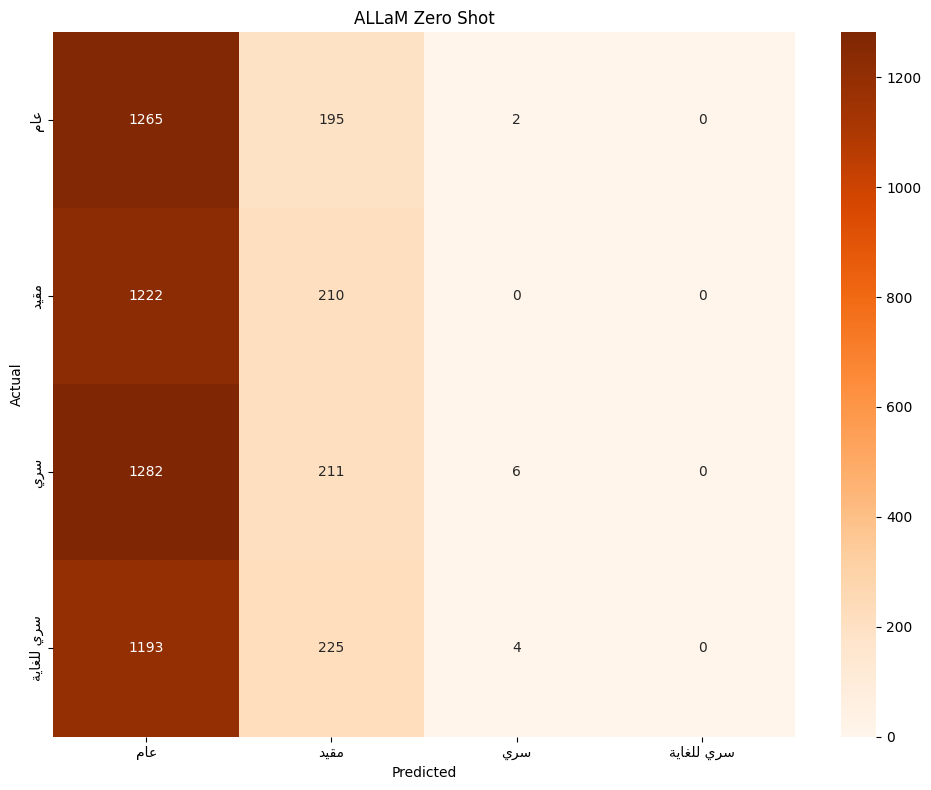

In [ ]:
def build_zero_shot_prompt(content):
    """Zero-shot prompt: system instruction only, no examples."""
    system = "أنت مساعد ذكي خبير في تصنيف الوثائق السعودية حسب معايير NDMO. صنف النص التالي إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    return f"### نظام:\n{system}\n\n### مستخدم:\nالوثيقة: {content}\n\n### مساعد:\nالتصنيف المستهدف:"


ZERO_SHOT_FILE = f"{PROJECT_DIR}/allam_ndmo_results.csv"
contents    = test_df['content'].tolist()
true_labels = test_df['sensitivity_level'].tolist()

run_inference(contents, true_labels, build_zero_shot_prompt, ZERO_SHOT_FILE)
evaluate_and_plot(ZERO_SHOT_FILE, "ALLaM Zero-Shot")


## 5. One-Shot Evaluation
One labeled example per sensitivity class provided in the prompt.

Loading base model and tokenizer...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Base model loaded successfully!
Test samples loaded: 6000
Resuming — 6000 already processed.
Remaining: 0 documents

Running 1-Shot evaluation...



1-Shot Inference: 0it [00:00, ?it/s]


Performance Report (1-Shot - Base Model):
              precision    recall  f1-score   support

      Public       0.28      0.96      0.44      1515
  Restricted       0.31      0.14      0.19      1465
      Secret       0.30      0.04      0.07      1519
  Top Secret       0.76      0.02      0.03      1501

    accuracy                           0.29      6000
   macro avg       0.42      0.29      0.18      6000
weighted avg       0.42      0.29      0.18      6000



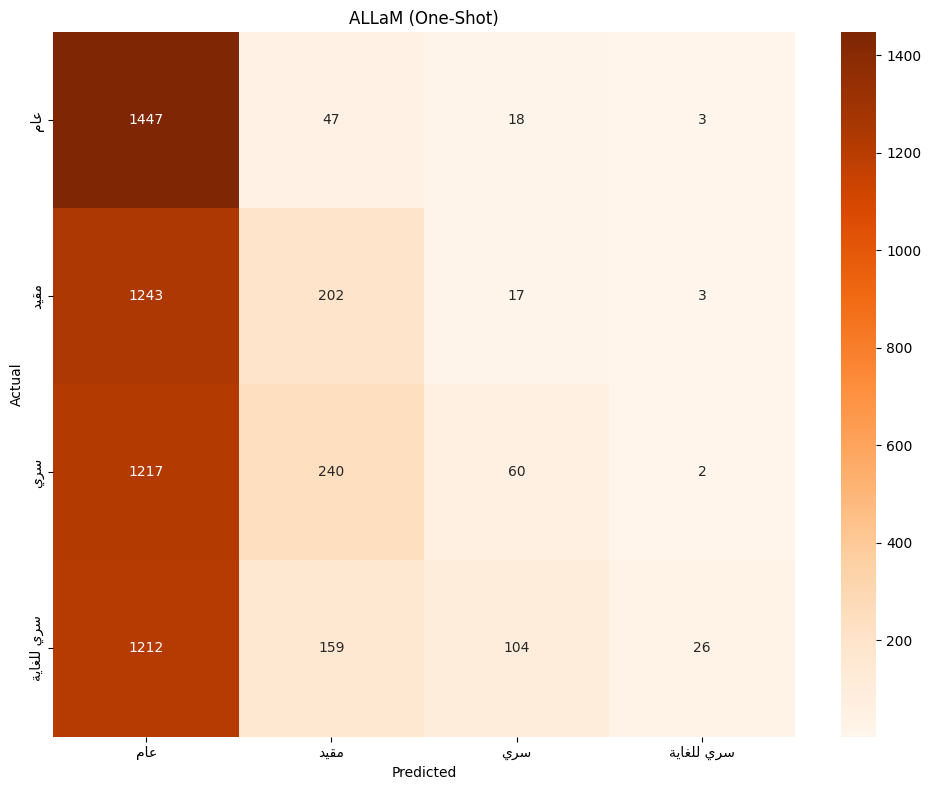

Results saved to: /content/drive/MyDrive/allam_project/1shot_results.csv


In [ ]:
def build_one_shot_prompt(content):
    """One-shot prompt: one example per sensitivity class."""
    system = "أنت مساعد ذكي وخبير إداري متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    examples = """
أمثلة توضيحية:
الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع وتكريم المتميزين.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية للربع القادم.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية للمنظمة.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية، إفشاؤها يسبب ضرراً بالغاً بالأمن الوطني.
التصنيف: سري للغاية
"""
    return f"### نظام:\n{system}\n\n### مستخدم:\n{examples}\nالآن، صنف الوثيقة الحالية:\nالوثيقة: {content}\n\n### مساعد:\nالتصنيف الصحيح هو: "


ONE_SHOT_FILE = f"{PROJECT_DIR}/1shot_results.csv"
run_inference(contents, true_labels, build_one_shot_prompt, ONE_SHOT_FILE)
evaluate_and_plot(ONE_SHOT_FILE, "ALLaM One-Shot")



## 6. Three-Shot Evaluation
Three labeled examples per class for richer context.

Test samples loaded: 6000
Resuming — 6000 already processed.
Remaining: 0 documents

Running 3-Shot evaluation...


3-Shot Inference: 0it [00:00, ?it/s]


Performance Report (3-Shot - Base Model):
              precision    recall  f1-score   support

      Public       0.39      0.62      0.48      1515
  Restricted       0.27      0.66      0.38      1465
      Secret       0.35      0.01      0.02      1519
  Top Secret       0.00      0.00      0.00      1501

    accuracy                           0.32      6000
   macro avg       0.25      0.32      0.22      6000
weighted avg       0.25      0.32      0.22      6000




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


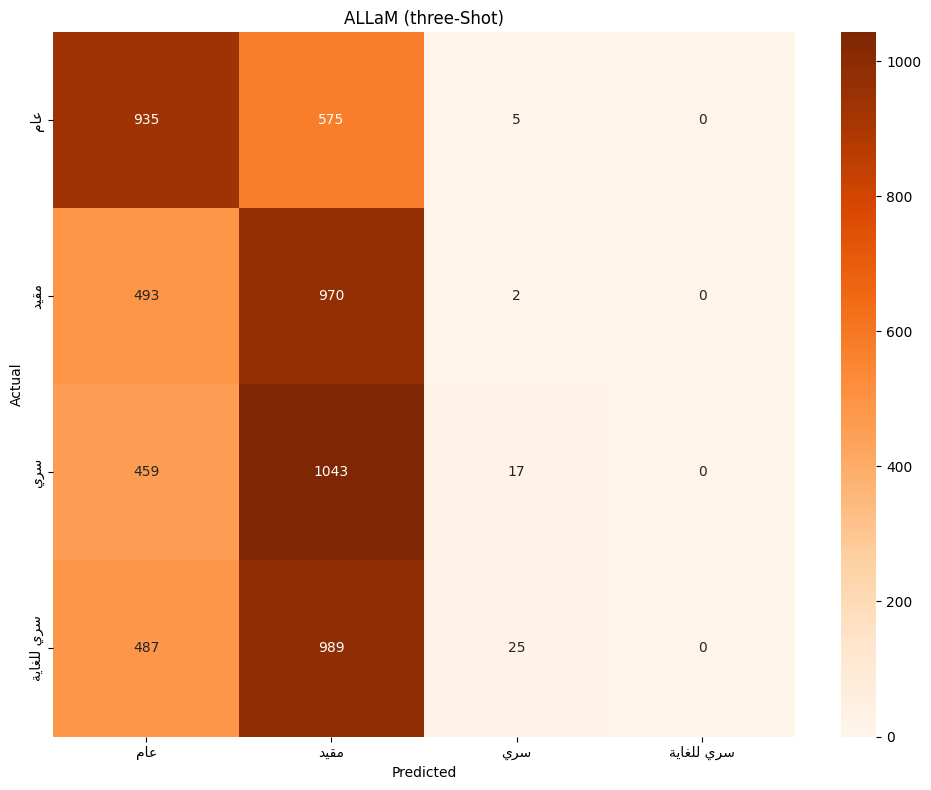

Results saved to: /content/drive/MyDrive/allam_project/3shot_results.csv


In [ ]:
def build_three_shot_prompt(content):
    """Three-shot prompt: three examples per sensitivity class."""
    system = "أنت مساعد ذكي وخبير إداري متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."
    examples = """
أمثلة مرجعية:
الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع.
التصنيف: عام
الوثيقة: دليل استخدام البوابة الإلكترونية للموظفين الجدد.
التصنيف: عام
الوثيقة: تقرير إحصائي منشور يوضح أعداد المستفيدين من الخدمات الحكومية.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية.
التصنيف: مقيد
الوثيقة: تعميم داخلي موجه لرؤساء الأقسام بشأن تغييرات في الهيكل التنظيمي.
التصنيف: مقيد
الوثيقة: مسودة مشروع تطويري داخلي لا تزال قيد المراجعة.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية.
التصنيف: سري
الوثيقة: تفاصيل العروض المالية والفنية المقدمة من الشركات لمنافسة حكومية قبل الترسية.
التصنيف: سري
الوثيقة: مذكرات قانونية تتعلق بقضايا قائمة ضد المنظمة قد تؤثر على سمعتها.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية تمس الأمن الوطني.
التصنيف: سري للغاية
الوثيقة: محضر اجتماع مجلس الوزراء المتعلق بقرارات سيادية عليا.
التصنيف: سري للغاية
الوثيقة: شيفرات التشفير الوطنية أو تفاصيل المواقع العسكرية الحساسة.
التصنيف: سري للغاية
"""
    return f"### نظام:\n{system}\n\n### مستخدم:\n{examples}\nالآن، صنف الوثيقة الحالية:\nالوثيقة: {content}\n\n### مساعد:\nالتصنيف الصحيح هو: "


THREE_SHOT_FILE = f"{PROJECT_DIR}/3shot_results.csv"
run_inference(contents, true_labels, build_three_shot_prompt, THREE_SHOT_FILE, max_length=2048)
evaluate_and_plot(THREE_SHOT_FILE, "ALLaM Three-Shot")
